# University Physics with Modern Physics

<img src="..//pics/cover.png" width=400> 



In [9]:
import setuptools

print("setuptools version:", setuptools.__version__)  # Should be < 70.0.0

import vpython as vp
from astropy import units as u
from astropy import constants as const
import sympy as sp
import numpy as np
from IPython.display import display, Math
import matplotlib.pyplot as plt
import sys
from pathlib import Path

print("All imports succeeded!")

setuptools version: 69.5.1
All imports succeeded!


In [10]:
# Add root folder to sys.path
sys.path.append(str(Path("..").resolve()))

# Import your helper function directly
from helper_functions import fmt_vec, plot_vector, plot_vector_xy, math_bearing


In [11]:
!python --version

Python 3.12.10


In [12]:
pwd


'c:\\Users\\crodr\\BK_tech\\Physics\\BK_University_Physics_Young_15\\ch01'

# 1 Units, Physical Quantities, and Vectors
## Problems Section 
### Challenge


1.90

page 60

••• Drone Delivery. You are testing parcel delivery by drone for
a project. Your team uses vector displacements to record the route of
the drone, with the origin taken to be the position of the control centre.
During one test, the drone starts its flight at $10\hat{i} - 50\hat{j}$, where
the units are meters, $\hat{i}$ is to the east, and $\hat{j}$ is to the north. Subsequent
displacements of the drone are $+90\hat{i}$, $+110\hat{j}$, $-60\hat{i} +40\hat{j}$, and
$+120\hat{i} +180\hat{j}$. If the final destination of the drone is $-70\hat{j}$, how far and
in which direction must the drone fly? (You are well advised to diagram
the situation before solving this numerically.)

In [13]:
# calculation cell
import vpython as vp

start = vp.vec(10, -50, 0)
l1 = vp.vec(90, 0, 0)
l2 = vp.vec(0, 110, 0)
l3 = vp.vec(-60, 40, 0)
l4 = vp.vec(120, 180, 0)
destination = vp.vec(0, -70, 0)

# End point of l4
end_l4 = start + l1 + l2 + l3 + l4

# l5 goes from end of l4 to destination
l5 = destination - end_l4

l5_mag = l5.mag
theta = vp.degrees(vp.atan2(l5.y, l5.x)) % 360

print(f"vector l5: {l5} m")
print(f"Magnitude |l5|: {l5_mag:.1f} m")
print(f"Direction: {theta:.1f}°")

vector l5: <-160, -350, 0> m
Magnitude |l5|: 384.8 m
Direction: 245.4°


##### Ploting the Result

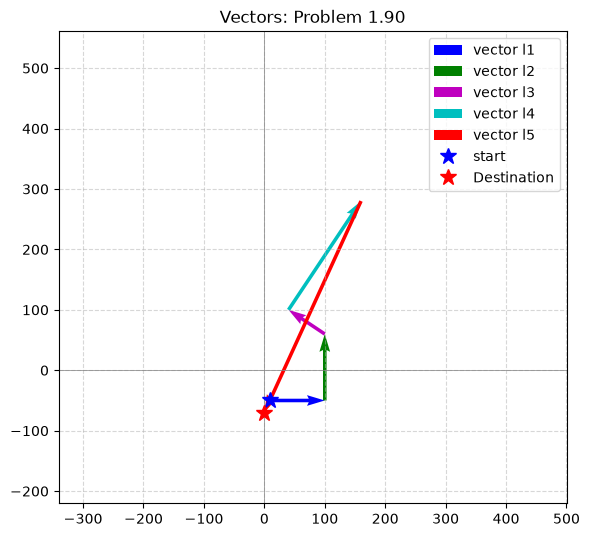

In [20]:
# NB: Run the previous cell because some values
# are taken from it.

fig, ax = plt.subplots(figsize=(6, 6))
ax.set_aspect("equal")
ax.axhline(0, color="gray", linewidth=0.5)
ax.axvline(0, color="gray", linewidth=0.5)
ax.grid(True, linestyle="--", alpha=0.5)

# Plot vectors
current = start
vec_l1 = plot_vector_xy(
    l1.x,
    l1.y,
    origin=(current.x, current.y),
    ax=ax,
    color="b",
    label="vector l1",
)
current += l1

vec_l2 = plot_vector_xy(
    l2.x,
    l2.y,
    origin=(current.x, current.y),
    ax=ax,
    color="g",
    label="vector l2",
)
current += l2

vec_l3 = plot_vector_xy(
    l3.x,
    l3.y,
    origin=(current.x, current.y),
    ax=ax,
    color="m",
    label="vector l3",
)
current += l3

vec_l4 = plot_vector_xy(
    l4.x,
    l4.y,
    origin=(current.x, current.y),
    ax=ax,
    color="c",
    label="vector l4",
)
current += l4

vec_l5 = plot_vector_xy(
    l5.x,
    l5.y,
    origin=(current.x, current.y),
    ax=ax,
    color="r",
    label="vector l5",
)
current += l5


# --- Add an asterisk at starting and at destination point ---
ax.plot(start.x, start.y, "b*", markersize=12, label="start")
ax.plot(destination.x, destination.y, "r*", markersize=12, label="Destination")

ax.legend()
plt.title("Vectors: Problem 1.90")

# --- Move legend below the plot ---
# ax.legend(bbox_to_anchor=(0.5, -0.15), loc='upper center', framealpha=0.9, ncol=1)
# # Expand figure bounds so the outside legend isn't cut off
# plt.tight_layout()


plt.tight_layout()
plt.show()

#### 1.91 
page 60

<img src="..//pics/Fig_P1_91.png" width=500> 


••• Navigating in the Big Dipper. All of the stars of the Big
Dipper (part of the constellation Ursa Major) may appear to be the
same distance from the earth, but in fact they are very far from each
other. Figure P1.91 shows the distances from the earth to each of
these stars. The distances are given in light-years (ly), the distance
that light travels in one year. One light-year equals $9.461 \times 10^{15} m$.


**(a)** Alkaid and Merak are 25.6° apart in the earth’s sky. In a diagram,
show the relative positions of Alkaid, Merak, and our sun. Find the
distance in light-years from Alkaid to Merak. 

**(b)** To an inhabitant of
a planet orbiting Merak, how many degrees apart in the sky would
Alkaid and our sun be?

In [ ]:
# --- Given data ---
theta_S_deg = 25.6
theta_S_rad = vp.radians(theta_S_deg)
d_A = 138 * u.lyr
d_M = 77 * u.lyr

# Part (a): Distance from Alkaid to Merak
# Law of Cosines
# d_AM^2 = d_A^2 + d_M^2 -2d_A d_M cos(theta_S) ==> d_AM = sqrt(d_A^2 + d_M^2 -2d_A d_M cos(theta_S))
d_AM = (d_A**2 + d_M**2 - 2 * d_A * d_M * vp.cos(theta_S_rad)) ** (1 / 2)

print("(a)")
print(f"Distance from Alkaid to Merak: {d_AM:.1f}")

# Part (b): Angular separation viewed from Merak
# Law of Sines
# sin(theta_M) / d_A = sin(theta_S) / d_AM ==> theta_M = asin((d_A sin(theta_S)) / d_AM)

theta_M_deg = vp.degrees(vp.asin((d_A * vp.sin(theta_S_rad)) / d_AM))
# Since Alkaid is further from the Sun than Merak, the angle at Merak is obtuse \theta_M > 90 deg

theta_M_deg = 180 - theta_M_deg

print()
print("(b)")
print(f"Angular separation at Merak: {theta_M_deg:.1f}°")


(a)
Distance from Alkaid to Merak: 76.2 lyr

(b)
Angular separation at Merak: 128.5°


##### Ploting the Result

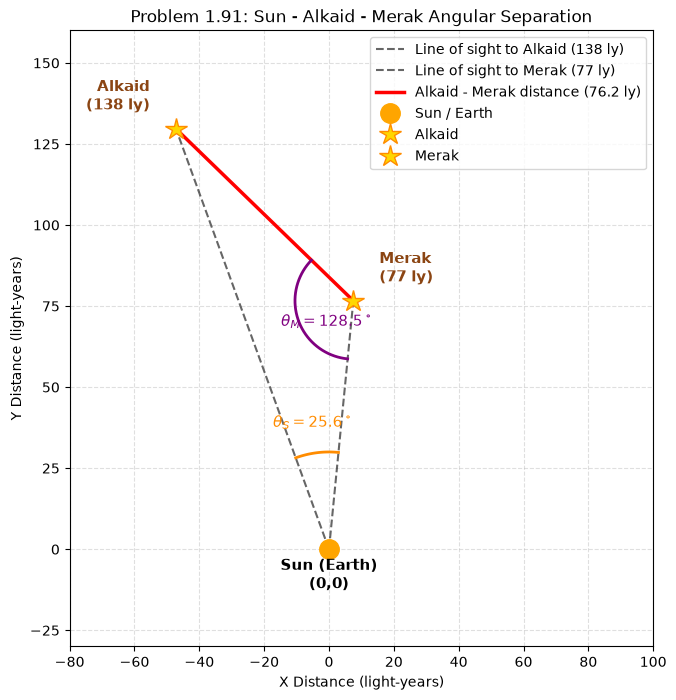

In [ ]:
# 1. Geometry Setup
theta_S_deg = 25.6
theta_S_rad = np.radians(theta_S_deg)

sun_pos = np.array([0.0, 0.0])

angle_A_rad = np.radians(110)
d_A = 138.0
alkaid_pos = np.array([d_A * np.cos(angle_A_rad), d_A * np.sin(angle_A_rad)])

angle_M_rad = angle_A_rad - theta_S_rad
d_M = 77.0
merak_pos = np.array([d_M * np.cos(angle_M_rad), d_M * np.sin(angle_M_rad)])

# 2. Figure Setup
fig, ax = plt.subplots(figsize=(9, 8))
ax.set_aspect("equal")
ax.grid(True, linestyle="--", alpha=0.4)

# Lines of sight and side AM
ax.plot(
    [sun_pos[0], alkaid_pos[0]],
    [sun_pos[1], alkaid_pos[1]],
    "k--",
    alpha=0.6,
    label="Line of sight to Alkaid (138 ly)",
)
ax.plot(
    [sun_pos[0], merak_pos[0]],
    [sun_pos[1], merak_pos[1]],
    "k--",
    alpha=0.6,
    label="Line of sight to Merak (77 ly)",
)
ax.plot(
    [alkaid_pos[0], merak_pos[0]],
    [alkaid_pos[1], merak_pos[1]],
    "r-",
    linewidth=2.5,
    label="Alkaid - Merak distance (76.2 ly)",
)

# Celestial Objects
ax.plot(
    sun_pos[0],
    sun_pos[1],
    "o",
    color="orange",
    markersize=14,
    label="Sun / Earth",
)
ax.plot(
    alkaid_pos[0],
    alkaid_pos[1],
    "*",
    color="gold",
    markeredgecolor="darkorange",
    markersize=16,
    label="Alkaid",
)
ax.plot(
    merak_pos[0],
    merak_pos[1],
    "*",
    color="gold",
    markeredgecolor="darkorange",
    markersize=16,
    label="Merak",
)

# Labels
ax.text(
    sun_pos[0],
    sun_pos[1] - 12,
    "Sun (Earth)\n(0,0)",
    fontsize=11,
    fontweight="bold",
    ha="center",
)
ax.text(
    alkaid_pos[0] - 8,
    alkaid_pos[1] + 6,
    "Alkaid\n(138 ly)",
    fontsize=11,
    fontweight="bold",
    color="saddlebrown",
    ha="right",
)
ax.text(
    merak_pos[0] + 8,
    merak_pos[1] + 6,
    "Merak\n(77 ly)",
    fontsize=11,
    fontweight="bold",
    color="saddlebrown",
    ha="left",
)

# Arc at Sun (25.6°)
arc_angles_sun = np.linspace(angle_M_rad, angle_A_rad, 40)
r_sun = 30.0
ax.plot(
    r_sun * np.cos(arc_angles_sun),
    r_sun * np.sin(arc_angles_sun),
    "darkorange",
    linewidth=2,
)
mid_sun = (angle_A_rad + angle_M_rad) / 2
ax.text(
    (r_sun + 8) * np.cos(mid_sun),
    (r_sun + 8) * np.sin(mid_sun),
    r"$\theta_S = 25.6^\circ$",
    fontsize=11,
    color="darkorange",
    fontweight="bold",
    ha="center",
)

# Arc at Merak (128.5°) — Interior Sweep Fix
vec_MS = sun_pos - merak_pos
vec_MA = alkaid_pos - merak_pos

angle_MS_rad = np.arctan2(vec_MS[1], vec_MS[0])
angle_MA_rad = np.arctan2(vec_MA[1], vec_MA[0])

diff = (angle_MA_rad - angle_MS_rad) % (2 * np.pi)
if diff > np.pi:
    arc_angles_merak = np.linspace(angle_MA_rad, angle_MA_rad + (2 * np.pi - diff), 40)
else:
    arc_angles_merak = np.linspace(angle_MS_rad, angle_MS_rad + diff, 40)

r_merak = 18.0
ax.plot(
    merak_pos[0] + r_merak * np.cos(arc_angles_merak),
    merak_pos[1] + r_merak * np.sin(arc_angles_merak),
    "purple",
    linewidth=2,
)

mid_merak = arc_angles_merak[len(arc_angles_merak) // 2]
ax.text(
    merak_pos[0] + (r_merak + 6) * np.cos(mid_merak),
    merak_pos[1] + (r_merak + 6) * np.sin(mid_merak),
    r"$\theta_M = 128.5^\circ$",
    fontsize=11,
    color="purple",
    fontweight="bold",
    ha="left",
    va="bottom",
)

# Axis Limits
ax.set_xlim(-80, 100)
ax.set_ylim(-30, 160)
ax.set_xlabel("X Distance (light-years)")
ax.set_ylabel("Y Distance (light-years)")
plt.title("Problem 1.91: Sun - Alkaid - Merak Angular Separation", fontsize=12)
ax.legend(loc="upper right")

plt.show()